In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.holtwinters import ExponentialSmoothing

here = Path.cwd()
DATA_PATH = None
for base in [here, *here.parents]:
    hit = base / "clean_data" / "Model_Ready.csv"
    if hit.exists():
        DATA_PATH = hit
        break

df = pd.read_csv(DATA_PATH, parse_dates=["month"])
df = df.sort_values("month").set_index("month").asfreq("MS")

print("Found file at:", DATA_PATH)
print("Date range:", df.index.min().date(), "->", df.index.max().date())
print("Rows:", len(df))

Found file at: /Users/divena/coding projects/mse-401-team-6/clean_data/Model_Ready.csv
Date range: 2015-01-01 -> 2026-06-01
Rows: 138


In [24]:
TARGET          = "total_people_served"
SEASONAL_PERIOD = 12
TRAIN_END       = "2025-06-01"
TEST_START      = "2025-07-01"

TIME_RANGES = {
    "TR1 (2019 start)": "2019-01-01",
    "TR2 (2022 start)": "2022-01-01",
}

series = df[TARGET]

In [25]:
def split_train_test(s, train_start, train_end, test_start):
    return s.loc[train_start:train_end], s.loc[test_start:]

In [26]:
def holt_winters_forecast(train, test, m, trend="add", seasonal="add", damped=False):
    model = ExponentialSmoothing(
        train,
        trend=trend,            # "add" = linear trend
        seasonal=seasonal,      # "add" or "mul"
        seasonal_periods=m,
        damped_trend=damped,    # damping pulls a strong trend back toward flat over the horizon
        initialization_method="estimated",
    )
    fit = model.fit()
    fc = fit.forecast(len(test))
    fc.index = test.index
    return fc

In [27]:
from sklearn.metrics import r2_score

def evaluate(actual, predicted):
    actual, predicted = actual.align(predicted, join="inner")
    err = actual - predicted
    return {
        "MAE":    round(np.mean(np.abs(err)), 1),
        "RMSE":   round(np.sqrt(np.mean(err**2)), 1),
        "WAPE %": round(np.sum(np.abs(err)) / np.sum(np.abs(actual)) * 100, 2),
        "R2":     round(r2_score(actual, predicted), 3),
    }

In [28]:
# We try four sensible configs. Additive vs multiplicative seasonality, and
# damped vs undamped trend. Your series plateaus near the split, so damped
# trend is worth testing — it may fit that flattening better.
CONFIGS = {
    "HW add/add":          dict(trend="add", seasonal="add", damped=False),
    "HW add/add damped":   dict(trend="add", seasonal="add", damped=True),
    "HW add/mul":          dict(trend="add", seasonal="mul", damped=False),
    "HW add/mul damped":   dict(trend="add", seasonal="mul", damped=True),
}

results = []
for label, train_start in TIME_RANGES.items():
    train, test = split_train_test(series, train_start, TRAIN_END, TEST_START)
    for cfg_name, cfg in CONFIGS.items():
        try:
            fc = holt_winters_forecast(train, test, SEASONAL_PERIOD, **cfg)
            results.append({"time_range": label, "model": cfg_name, **evaluate(test, fc)})
        except Exception as e:
            results.append({"time_range": label, "model": cfg_name,
                            "MAE": None, "RMSE": None, "WAPE %": None, "R2": None,
                            "error": str(e)})

results_df = pd.DataFrame(results).sort_values(["time_range", "WAPE %"])
results_df

,time_range,model,MAE,RMSE,WAPE %,R2
1,TR1 (2019 start),HW add/add damped,2662.3,2871.7,4.76,0.086
0,TR1 (2019 start),HW add/add,3097.9,3455.6,5.54,-0.323
3,TR1 (2019 start),HW add/mul damped,3423.9,3979.9,6.13,-0.755
2,TR1 (2019 start),HW add/mul,3658.0,4247.0,6.54,-0.999
4,TR2 (2022 start),HW add/add,2739.1,3359.9,4.90,-0.251
5,TR2 (2022 start),HW add/add damped,3126.8,3533.5,5.59,-0.383
6,TR2 (2022 start),HW add/mul,3167.7,4093.0,5.67,-0.856
7,TR2 (2022 start),HW add/mul damped,3180.7,3995.7,5.69,-0.769


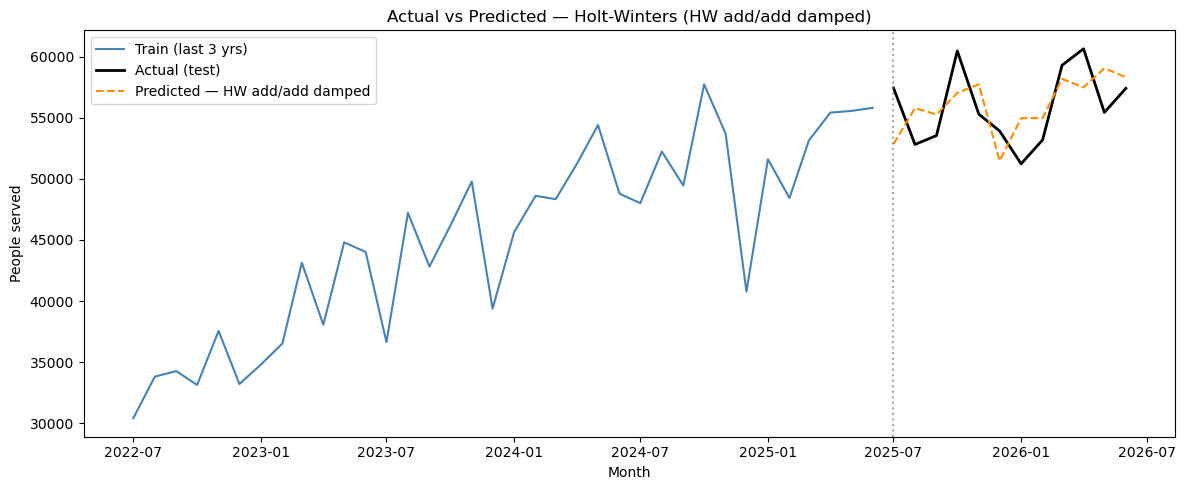

In [29]:
# Pick the lowest-WAPE config on TR1 to visualize
tr1 = results_df[results_df["time_range"] == "TR1 (2019 start)"]
best_name = tr1.iloc[0]["model"]
best_cfg  = CONFIGS[best_name]

train, test = split_train_test(series, TIME_RANGES["TR1 (2019 start)"], TRAIN_END, TEST_START)
fc = holt_winters_forecast(train, test, SEASONAL_PERIOD, **best_cfg)

plt.figure(figsize=(12, 5))
plt.plot(train.index[-36:], train.iloc[-36:], label="Train (last 3 yrs)", color="steelblue")
plt.plot(test.index, test, label="Actual (test)", color="black", linewidth=2)
plt.plot(fc.index,   fc,   label=f"Predicted — {best_name}", linestyle="--", color="darkorange")
plt.axvline(pd.Timestamp(TEST_START), color="grey", linestyle=":", alpha=0.7)
plt.title(f"Actual vs Predicted — Holt-Winters ({best_name})")
plt.xlabel("Month"); plt.ylabel("People served")
plt.legend(); plt.tight_layout()
plt.show()

## Holt-Winters Results - Summary

**Target:** `total_people_served` (monthly, agency level)
**Test period:** July 2025 onwards
**Configs tested:** additive/multiplicative seasonality × damped/undamped trend, across two training ranges
**Metrics:** MAE, RMSE, WAPE, R²

### Key Takeaways

- **Additive trend + additive seasonality + damped trend** was the best configuration in both time ranges, winning on every metric. Damping is essential, it was the *only* config to achieve a positive R² (0.086 on TR1), while all undamped and multiplicative configs scored **negative R²**, meaning they forecast worse than a flat average by overshooting the plateau.
- **WAPE is strong (~4.8%)**: the model's total error is under 5% of total actuals, which is solid for operational use.
- **R² is low (0.086 on TR1, negative on TR2).** This is expected on a plateauing, trend-dominated series: there is little variance around the level for the model to "explain," so R² stays low even when absolute error is small. WAPE is the more informative metric here.
- **TR1 (2019 start) outperforms TR2 (2022 start)** on every metric, most notably R² (0.086 vs −0.251), suggesting the additional pre-2022 history helps the model estimate trend and seasonal structure more reliably.
- **Feature importance: N/A** — Holt-Winters uses only the target's own history and has no external input features.

### Overall

Holt-Winters with damped additive trend and additive seasonality is the best classical configuration, achieving ~4.8% WAPE. The low/negative R² across configs reflects how difficult this plateauing series is to beat a flat baseline on, rather than a flaw in the model. Holt-Winters remains the more defensible operational choice over Naive because it explicitly models seasonal structure and tracks month-to-month movement, which matters for 3-month-ahead planning.